<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>This notebook takes a functional directory, a static directory, and a single-color control directory as inputs and:</p>
  <ol>
    <li>interleaves ch1 (red) and ch2 (green) functional images</li>
    <li>runs suite2p on the interleaved images</li>
    <li>verifies that imaging settings (laser power, PMTs, filter sets) in static directory are compatible with those in single-color directory</li>
    <li>aligns static images to master stack (depth correction + rigid xy shift)</li>
    <li>aligns master stack (and, along with it, all static images) to ch1 functional image (time average; looks for plane of master stack that, after a rigid xy shift, best matches functional image)</li>
    <li>runs cellpose on the best-match plane of the master stack to generate a classification template</li>
    <li>classifies single pixels within this template according to how similar their response profiles are to those of the single-color controls</li>
    <li>classifies cellpose ROIs based on the fraction of pixels inside them that are classified as a particular color
    <li>extracts functional traces for the cellpose ROIs, along with functional ROIs identified by suite2p (with overlap between these two sets of ROIs removed)</li>
  </em></li>
  </ol>
</div>

<div style="font-size: 1.8em; line-height: 1.5em; color: red">
  <p>Issues</p>
  <ol>
    <li>should be two routes through the script (classification + traces vs. classification only) (DONE)</li>
    <li>quality control figures for static/functional registration + classification (save results) (DONE)</li>
    <li>generalize pipeline to allow N>=3 classification channels (DONE)</li>
    <li>combine suite2p functional ROIs and cellpose-identified ROIs into one group of ROIs, with no double-counting (partly DONE, overlap added)</li>
    <li>results of last step should be viewable in suite2p GUI (DONE)</li>
    <li>fix overwrite checks (not working because of file extensions) (DONE)</li>
    <li>erode cellpose ROIs (n layers) to make sure we aren't catching any background? (DONE)</li>
    <li>fix cellpose ROI trace extractiont to work when suite2p outputs multiple binary files (DONE)</li>
    <li>change script to run on a list of file paths, not just one path</li>
    <li>save script settings for later reference (DONE)</li>
    <li>cellpose best practices / what to do if the automatic mode fails for some reason?</li>
    <li>ask about isredcell issue in suite2p github (FIXED)</li>
    <li>add safety boundary to z-shift + xy-shift</li>
    <li>batch processing / warnings when things go wrong and you are not monitoring closely</li>
    <li>double-check neuropil extraction for cellpose ROIs</li>
    <li>add spike detection for cellpose ROIs</li>
  </em></li>
  </ol>
</div>

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Imports and helper functions</p>
</div>

In [1]:
import os
import pandas as pd
from glob import glob
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
from matplotlib import colors as mcolors

import re
from itertools import combinations
import xml.etree.ElementTree as ET
import tiffile as tf
from matplotlib import colors
from scipy import ndimage as ndi
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label
from scipy.special import softmax
from skimage.registration import phase_cross_correlation
from skimage import io
from skimage import measure
import cellpose
import suite2p

# font sizes
BASE = 12
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.weight": "regular", "font.size": BASE,
    "axes.titlesize": int(BASE*1.6), "axes.labelsize": int(BASE*1.35),
    "figure.titlesize": int(BASE*1.6), "legend.title_fontsize": int(BASE*1.15),
    "legend.fontsize": BASE, "xtick.labelsize": BASE, "ytick.labelsize": BASE,
})

# helper functions
def scrape_xml(channel_path):
    # load xml (what's the difference between xml and env here?)
    xml_path = glob(os.path.join(channel_path, "*.xml"))[0]
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # pmt settings
    tag_name = "PVStateValue"
    attr_name = "key"
    attr_value = "pmtGain"
    pmt = root.find(f".//{tag_name}[@{attr_name}='{attr_value}']")[0].get('value')

    # laser power
    tag_name = "PVStateValue"
    attr_name = "key"
    attr_value = "laserPower"
    laser_power = root.find(f".//{tag_name}[@{attr_name}='{attr_value}']")[0].get('value')
    
    # laser wavelength
    tag_name = "PVStateValue"
    attr_name = "key"
    attr_value = "laserWavelength"
    laser_wavelength = root.find(f".//{tag_name}[@{attr_name}='{attr_value}']")[0].get('value')
    
    return {'pmt': pmt, 'laser_power': laser_power, 'laser_wavelength': laser_wavelength}

def register(channel_dict):
    # find brightest image, use this as reference (by default, take middle slice)
    num_slices = []
    mean_val_md = []
    for i in range(len(channel_dict['filter'])):
        image = io.imread(channel_dict['full path'][i])
        num_slices.append(image.shape[0])
        md_idx = int(np.round(num_slices[i]/2))
        mean_val_md.append(np.mean(image[md_idx, :, :]))
        #axs[i].imshow(image[10, :, :])
        #image = gaussian_filter(image, sigma=smoothing_std)

    if len(np.unique(np.array(num_slices)))!=1:
        print('Warning: different stack geometry in different channels.')
    
    ref_idx = np.argmax(np.array(mean_val_md))
    ref_image = io.imread(channel_dict['full path'][ref_idx])
    ref_image = ref_image[md_idx, :, :]

    channel_cats = []
    for i in range(len(channel_dict['filter'])):
        image = io.imread(channel_dict['full path'][i])
        reg_qual = []
        for j in range(image.shape[0]):
            shift_estimate, _, _ = phase_cross_correlation(ref_image, image[j, :, :], upsample_factor=10)
            registered_image = shift(image[j, :, :], shift=shift_estimate, mode='nearest')
            reg_qual.append(np.corrcoef(registered_image.flatten(), ref_image.flatten())[0, 1])
            
        best_qual = np.argmax(np.array(reg_qual))
        #print('registration quality: ' + str(reg_qual[best_qual]))
        shift_estimate, _, _ = phase_cross_correlation(ref_image, image[best_qual, :, :], upsample_factor=10)
        registered_image = shift(image[best_qual, :, :], shift=shift_estimate, mode='nearest')
        #registered_image = registered_image-np.quantile(registered_image, noise_quant) # background subtract
        channel_cats.append(registered_image.flatten())

    channel_cats = np.column_stack(channel_cats)
    
    return channel_cats


# for each plane in channel #ref_stack_idx, search for best matches in other channels
def register_to_one_stack(channel_dict, ref_stack_idx):
    # check number of slices in each channel
    num_planes = []
    for i in range(len(channel_dict['filter'])):
        image = io.imread(channel_dict['full path'][i])
        num_planes.append(image.shape[0])
        
    if len(np.unique(np.array(num_planes)))!=1:
        print('Warning: different stack geometry in different channels.')

    num_planes = num_planes[0]
    
    all_reg = []
    ref_stack = io.imread(channel_dict['full path'][ref_stack_idx])
    for n in range(num_planes):
        ref_image = ref_stack[n, :, :]
        temp_reg = []
        for i in range(len(channel_dict['filter'])):
            print([n, i])
            stack = io.imread(channel_dict['full path'][i])
            reg_qual = []
            for n2 in range(num_planes):
                shift_estimate, _, _ = phase_cross_correlation(ref_image, stack[n2, :, :], upsample_factor=10)
                registered_image = shift(stack[n2, :, :], shift=shift_estimate, mode='nearest')
                reg_qual.append(np.corrcoef(registered_image.flatten(), ref_image.flatten())[0, 1])
            reg_qual = np.array(reg_qual)
            #print('registration quality = ' + str(np.max(reg_qual)))
            best_qual_image = stack[np.argmax(reg_qual), :, :]
            shift_estimate, _, _ = phase_cross_correlation(ref_image, best_qual_image, upsample_factor=10)
            registered_image = shift(best_qual_image, shift=shift_estimate, mode='nearest')
            #registered_image = registered_image-np.quantile(registered_image, noise_quant) # background subtraction
            temp_reg.append(registered_image.flatten())

        temp_reg = np.column_stack(temp_reg) # in final format nPixels x nChannels
        all_reg.append(temp_reg) # all_reg will eventually have size (nPlanes,)

    return all_reg


# plotting
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        # Return z-depth for sorting; any scalar is fine
        return np.min(zs)

def add_arrow3d(ax, start, end, *, arrowstyle='-|>', mutation_scale=26, lw=2.5, alpha=0.95, **kwargs):
    x0, y0, z0 = start
    x1, y1, z1 = end
    a = Arrow3D([x0, x1], [y0, y1], [z0, z1],
                arrowstyle=arrowstyle, mutation_scale=mutation_scale,
                lw=lw, alpha=alpha, **kwargs)
    ax.add_artist(a)
    return a

def erode_rois(labels, nLayers, connectivity=1):

    if nLayers <= 0:
        return labels.copy()

    out = np.zeros_like(labels, dtype=labels.dtype)
    structure = ndi.generate_binary_structure(2, connectivity)

    for lab in np.unique(labels):
        if lab == 0:
            continue
        mask = labels == lab
        eroded = ndi.binary_erosion(mask, structure=structure, iterations=nLayers, border_value=0)
        out[eroded] = lab

    return out

def labels_to_stat(labels):
    """
    Convert an integer-labeled ROI image into a list of Suite2p-style `stat` dicts.
    labels: 2D array (Ly x Lx) with 0=background, 1..N = ROI ids
    """
    Ly = labels.shape[1]
    Lx = labels.shape[0]
    
    stats = []
    max_label = int(labels.max())
    for roi_id in range(1, max_label + 1):
        ys, xs = np.where(labels == roi_id)
        if ys.size == 0:
            continue
        med = np.array([np.median(xs), np.median(ys)], dtype=np.float32)
        lam = np.ones(ys.size, dtype=np.float32)  # weights; uniform is fine for viewing
        npix = int(ys.size)
        radius = float(np.sqrt(npix / np.pi))     # a rough radius for display

        s = {
            'xpix': xs.astype(np.int32),
            'ypix': ys.astype(np.int32),
            'lam': lam
        }
        stats.append(s)
    return stats

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Pipeline settings (IMPORTANT!)</p>
</div>

In [2]:
with_func = True # if False, perform classification only; if True, perform classification and extract traces with suite2p
multi_dir = r"/Volumes/2P3_data/Sam/imaging_sessions/exp96.animal1/20250729" #r"/Volumes/2P3_data/Sam/imaging_sessions/exp96.animal1/20250717/FOV1" # r"/Volumes/2P3_data/Sam/unmixing_coefficients/spatial control mouse #1 20250722/stitched-images" # directory containing static images (i.e. has subdirectories of form RedEmFilt1180.../)
func_dir = "/Volumes/2P3_data/Sam/imaging_sessions/exp96.animal1/20250729/exp96.animal1.0um.2250729.gratings.no.puff.sal-017" # directory containing functional images (usually a subdirectory of multi_dir)
single_dir = r"/Volumes/2P3_data/Sam/unmixing_coefficients/3controlmice_3stacks_20250717" # directory containing single-color control images

classification_chan = {"filter": ["OrangeEmFilt", "RedEmFilt", "FarRedEmFilt"], "wavelength": [1040, 1180, 1240], "power": [298, 347, 493]} # channels used for 3-color classification
master_alignment_chan = {"filter": "BR2EmFilt", "wavelength": 1080} # channel used for alignment
plot_chan = {"filter": ["OrangeEmFilt", "RedEmFilt", "FarRedEmFilt"], "wavelength": [1040, 1180, 1240], "power": [298, 347, 493]} # channels used for plots that don't work in >3d

if len(plot_chan["filter"]) != 3:
    print("Error: should be three channels in plot_chan.")

power_tol = 3 # power tolerance (i.e. max amount we allow the laser power to deviate from its expected value)
cellpose_diameter = None # diameter used for cell segmentation (None = automatic)
nLayers_erode = 1 # number of layers of erosion to perform on cellpose ROIs
signal_quant_single_color = 0.99 # only consider pixels this bright or brighter when computing ground-truth response profiles from single-color controls
ROI_frac = 0.8 # pixel ratio threshold for classifying an ROI
overlap_threshold = 0.5 # max allowed overlap between cellpose 1080 ROIs and suite2p functional ROIs

# save settings
settings = {"with_func": with_func, "multi_dir": multi_dir, "func_dir": func_dir, "single_dir": single_dir, "classification_chan": classification_chan,
            "master_alignment_chan": master_alignment_chan, "plot_chan": plot_chan, "power_tol": power_tol, "cellpose_diameter": cellpose_diameter,
            "nLayers_erode": nLayers_erode, "signal_quant_single_color": signal_quant_single_color, "ROI_frac": ROI_frac, "overlap_threshold": overlap_threshold}

if with_func:
    settings_path = os.path.join(func_dir, "3color_settings")
else:
    settings_path = os.path.join(multi_dir, "3color_settings")

if len(glob(settings_path + ".*"))>0:
    print("Warning: overwriting previously saved settings.")
np.save(settings_path, settings)

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Interleave Ch2 (green) and Ch1 (red) functional images (in that order)</p>
</div>

In [6]:
if not with_func:
    print("Skipping this code block since with_func = False (classification only, no trace extraction)")
elif os.path.isdir(os.path.join(func_dir, "interleaved")):
    print("May have already been interleaved.")
else:
    all_dir = os.listdir(func_dir)
    ch1 = []
    ch2 = []
    for sub in all_dir:
        if "Ch1" in sub:
            ch1.append(sub)
        elif "Ch2" in sub:
            ch2.append(sub)
    
    ch1 = np.sort(ch1)
    ch2 = np.sort(ch2)
    
    print("channel 1 paths: \n")
    print(ch1)
    print("\n\nchannel 2 paths: \n")
    print(ch2)
    
    if len(ch1) != len(ch2):
        print("Error: mismatched tiffs for Ch1 and Ch2")
    else:
        # make interleaved directory under func_dir
        os.mkdir(os.path.join(func_dir, "interleaved"))
    
        # for each pair of Ch1/Ch2 tiffs, interleave and save result
        for i in range(len(ch1)):
            print("\nreading channel 1, image " + str(i))
            im1 = tf.imread(func_dir+"/"+ch1[i])
            print("\nreading channel 2, image " + str(i))
            im2 = tf.imread(os.path.join(func_dir, ch2[i]))
    
            interleaved_shape = list(im1.shape) # conver to list so mutable
            interleaved_shape[0] = 2*interleaved_shape[0] 
    
            interleaved_im = np.empty(interleaved_shape, dtype=im1.dtype)
    
            # order is important here: first channel 2 (green), then channel 1 (red)
            interleaved_im[0::2,:,:] = im2
            interleaved_im[1::2,:,:] = im1
    
            interleaved_path = os.path.join(os.path.join(func_dir, "interleaved"), ch1[i])
            interleaved_path = interleaved_path.replace("Ch1", "interleaved_Chs")
            tf.imwrite(interleaved_path, interleaved_im, imagej=True)

channel 1 paths: 

['exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch1_000001.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch1_000002.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch1_000003.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch1_000004.ome.tif']


channel 2 paths: 

['exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch2_000001.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch2_000002.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch2_000003.ome.tif'
 'exp96.animal1.0um.2250729.gratings.no.puff.sal-017_Cycle00001_Ch2_000004.ome.tif']

reading channel 1, image 0

reading channel 2, image 0

reading channel 1, image 1

reading channel 2, image 1

reading channel 1, image 2

reading channel 2, image 2

reading channel 1, image 3

reading channel 2, image 3


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Register and curate static images (sometimes slow)</p>
</div>

In [3]:
# organize static images: depth correction, rigid x-y shift correction, organizing into easy-to-access data structures

# single-color controls
fp_dict = {}
for dirname in os.listdir(single_dir):
    if os.path.isdir(os.path.join(single_dir, dirname)):
        fp_dir = os.path.join(single_dir, dirname)
        fluorophore_name = dirname.split('_')[0]
        image_dirnames = os.listdir(fp_dir)
        image_dirnames = [image_dirname for image_dirname in image_dirnames if os.path.isdir(os.path.join(fp_dir, image_dirname))]
        filters = []
        power = []
        wavelength = []
        pmt = []
        full_path = []
        for image_dirname in image_dirnames:
            if image_dirname[:3]=='BR2' or image_dirname[:3]=='Far' or image_dirname[:3]=='Ora' or image_dirname[:3]=='Red':
                xml_info = scrape_xml(os.path.join(fp_dir, image_dirname))
                filters.append(image_dirname.split('_')[0])
                power.append(float(xml_info['laser_power']))
                wavelength.append(float(xml_info['laser_wavelength']))
                pmt.append(float(xml_info['pmt']))
                full_path.append(glob(os.path.join(os.path.join(fp_dir, image_dirname), "*Ch1*.tif"))[0])
                    
        fp_dict[fluorophore_name] = {'filter': np.array(filters), 'power': np.array(power), 'wavelength': np.array(wavelength), 'pmt': np.array(pmt), 'full path': np.array(full_path)}

# curate images into nPixels x nChannels format (with registration that accounts for possible depth shift)
for fp in fp_dict.keys():
    fp_dict[fp]['channel cat'] = register(fp_dict[fp])

# multicolor mouse
image_dirnames = os.listdir(multi_dir)
image_dirnames = [image_dirname for image_dirname in image_dirnames if os.path.isdir(os.path.join(multi_dir, image_dirname))]

filters = []
power = []
wavelength = []
pmt = []
full_path = []
for image_dirname in image_dirnames:
    if image_dirname[:3]=='BR2' or image_dirname[:3]=='Far' or image_dirname[:3]=='Ora' or image_dirname[:3]=='Red':
        xml_info = scrape_xml(os.path.join(multi_dir, image_dirname))
        filters.append(image_dirname.split('_')[0])
        power.append(float(xml_info['laser_power']))
        wavelength.append(float(xml_info['laser_wavelength']))
        pmt.append(float(xml_info['pmt']))
        full_path.append(glob(os.path.join(os.path.join(multi_dir, image_dirname), "*Ch1*.tif"))[0])
        
multi_dict = {'filter': np.array(filters), 'power': np.array(power), 'wavelength': np.array(wavelength), 'pmt': np.array(pmt), 'full path': np.array(full_path)}

# find reference (master) stack
ref_stack_idx = np.where(np.logical_and(multi_dict['filter']==master_alignment_chan['filter'], multi_dict['wavelength']==master_alignment_chan['wavelength']))[0][0]
multi_dict['all reg'] = register_to_one_stack(multi_dict, ref_stack_idx)

# record original shape of images
example_image = io.imread(multi_dict['full path'][ref_stack_idx])
multi_dict['original shape'] = (example_image.shape[1], example_image.shape[2])

# check which channels in multi_dict are in classification_chan and plot_chan
in_classification_chan = []
in_plot_chan = []
for i in range(len(multi_dict['filter'])):
    present = np.logical_and(np.array(classification_chan['filter'])==multi_dict['filter'][i], 
                         np.logical_and(np.array(classification_chan['wavelength'])==multi_dict['wavelength'][i],
                         np.abs(np.array(classification_chan['power'])-multi_dict['power'][i])<power_tol))
    in_classification_chan.append(np.sum(1*present)>0)

    present = np.logical_and(np.array(plot_chan['filter'])==multi_dict['filter'][i], 
                         np.logical_and(np.array(plot_chan['wavelength'])==multi_dict['wavelength'][i],
                         np.abs(np.array(plot_chan['power'])-multi_dict['power'][i])<power_tol))
    in_plot_chan.append(np.sum(1*present)>0)

# calculate mean response in each channel for each FP (could change this to use cellpose, or add background subtraction)
for fp in fp_dict.keys():
    fp_dict[fp]['multi aligned'] = np.full((multi_dict['all reg'][0].shape[1], ), np.nan)
    pmt_FP = []
    for i in range(multi_dict['all reg'][0].shape[1]):
        filt = multi_dict['filter'][i]
        wavelength = multi_dict['wavelength'][i]
        power = multi_dict['power'][i]
        idx = np.where(np.logical_and(np.logical_and(fp_dict[fp]['wavelength']==wavelength, fp_dict[fp]['filter']==filt), np.abs(fp_dict[fp]['power']-power)<power_tol))[0]
        if len(idx)>0:
            curr = fp_dict[fp]['channel cat'][:, idx[0]]
            fp_dict[fp]['multi aligned'][i] = np.mean(curr[curr>np.quantile(curr, signal_quant_single_color)])
            pmt_FP.append(fp_dict[fp]['pmt'][idx[0]])
        else:
            pmt_FP.append(np.nan)
    if len(np.unique(np.divide(np.array(pmt_FP)[in_classification_chan], np.array(multi_dict['pmt'][in_classification_chan]))))>1:
        print("WARNING: PMT gain is scaled differently in single-color vs. multi-color images")

[0, 0]
[0, 1]
[0, 2]
[0, 3]
[1, 0]
[1, 1]
[1, 2]
[1, 3]
[2, 0]
[2, 1]
[2, 2]
[2, 3]
[3, 0]
[3, 1]
[3, 2]
[3, 3]
[4, 0]
[4, 1]
[4, 2]
[4, 3]
[5, 0]
[5, 1]
[5, 2]
[5, 3]
[6, 0]
[6, 1]
[6, 2]
[6, 3]
[7, 0]
[7, 1]
[7, 2]
[7, 3]
[8, 0]
[8, 1]
[8, 2]
[8, 3]
[9, 0]
[9, 1]
[9, 2]
[9, 3]
[10, 0]
[10, 1]
[10, 2]
[10, 3]
[11, 0]
[11, 1]
[11, 2]
[11, 3]
[12, 0]
[12, 1]
[12, 2]
[12, 3]
[13, 0]
[13, 1]
[13, 2]
[13, 3]
[14, 0]
[14, 1]
[14, 2]
[14, 3]
[15, 0]
[15, 1]
[15, 2]
[15, 3]
[16, 0]
[16, 1]
[16, 2]
[16, 3]
[17, 0]
[17, 1]
[17, 2]
[17, 3]
[18, 0]
[18, 1]
[18, 2]
[18, 3]
[19, 0]
[19, 1]
[19, 2]
[19, 3]
[20, 0]
[20, 1]
[20, 2]
[20, 3]
[21, 0]
[21, 1]
[21, 2]
[21, 3]
[22, 0]
[22, 1]
[22, 2]
[22, 3]
[23, 0]
[23, 1]
[23, 2]
[23, 3]
[24, 0]
[24, 1]
[24, 2]
[24, 3]
[25, 0]
[25, 1]
[25, 2]
[25, 3]
[26, 0]
[26, 1]
[26, 2]
[26, 3]
[27, 0]
[27, 1]
[27, 2]
[27, 3]
[28, 0]
[28, 1]
[28, 2]
[28, 3]
[29, 0]
[29, 1]
[29, 2]
[29, 3]
[30, 0]
[30, 1]
[30, 2]
[30, 3]
[31, 0]
[31, 1]
[31, 2]
[31, 3]
[32, 0]
[32, 1]


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Run suite2p</p>
</div>

In [11]:
# output is stored in func_dir/interleaved/suite2p folder
if not with_func:
    print("Skipping this code block since with_func = False (classification only, no trace extraction)")
elif os.path.isdir(os.path.join(os.path.join(func_dir, "interleaved"), "suite2p")):
    print("May have already ran suite2p.")
else:
    data_path = os.path.join(func_dir, "interleaved")
    ops = suite2p.default_ops()
    ops['data_path'] = [data_path]
    ops['save_path'] = data_path
    ops['fast_disk'] = data_path
    ops['batch_size'] = 300 # adjust based on your computer's RAM
    ops['roidetect'] = True
    ops['fs'] = 15 # sampling rate of recording, determines binning for cell detection
    ops['tau'] = 0.3 # timescale of gcamp to use for deconvolution
    ops['spikedetect'] = False # no spike detection
    ops['nonrigid'] = False # rigid motion correction
    ops['nchannels'] = 2 
    ops['reg_tif'] = False # save registered images as tif
    ops['reg_tif_chan2'] = False
    output_ops = suite2p.run_s2p(ops=ops)

{}
FOUND BINARIES AND OPS IN ['/Volumes/2P3_data/Sam/imaging_sessions/exp96.animal1/20250729/exp96.animal1.0um.2250729.gratings.no.puff.sal-017/interleaved/suite2p/plane0/ops.npy']
removing previous detection and extraction files, if present
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not running registration, ops['do_registration']=0
binary path: /Volumes/2P3_data/Sam/imaging_sessions/exp96.animal1/20250729/exp96.animal1.0um.2250729.gratings.no.puff.sal-017/interleaved/suite2p/plane0/data.bin
NOTE: applying default /Users/samsooter/.suite2p/classifiers/classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 04
Binned movie of size [3808,512,512] created in 1270.48 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 3.17, threshold 15.87 


/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:399: RuntimeWarning: divide by zero encountered in matmul
  tproj = mov[:, ypix0 * Lxc + xpix0] @ lam0
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:399: RuntimeWarning: overflow encountered in matmul
  tproj = mov[:, ypix0 * Lxc + xpix0] @ lam0
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:399: RuntimeWarning: invalid value encountered in matmul
  tproj = mov[:, ypix0 * Lxc + xpix0] @ lam0
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:199: RuntimeWarning: divide by zero encountered in matmul
  xproj = mpix @ lam
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:199: RuntimeWarning: overflow encountered in matmul
  xproj = mpix @ lam
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/detection/sparsedetect.py:199: R

0 ROIs, score=210.43
Detected 568 ROIs, 42.34 sec
After removing overlaps, 564 ROIs remain
>>>> CELLPOSE estimating masks in anatomical channel
>>>> 70 masks detected, median diameter = 15.00 
----------- Total 1319.54 sec.
----------- EXTRACTION
Masks created, 0.51 sec.


/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/suite2p/extraction/extract.py:125: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  Fi[n] = np.dot(data[:, cell_ipix[n]], cell_lam[n])


Extracted fluorescence from 564 ROIs in 15235 frames, 463.80 sec.
Extracted fluorescence from 564 ROIs in 15235 frames, 1032.70 sec.
----------- Total 1509.66 sec.
----------- CLASSIFICATION
['npix_norm', 'skew', 'compact']


/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/suite2p/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Plane 0 processed in 2868.42 sec (can open in GUI).
total = 2906.46 sec.
TOTAL RUNTIME 2906.46 sec


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Make figure directory</p>

In [12]:
if with_func:
    fig_dir = os.path.join(func_dir, "figs")
else:
    fig_dir = os.path.join(multi_dir, "figs")

if not os.path.isdir(fig_dir):
    os.mkdir(fig_dir)
else:
    print("May have already made figures.")

May have already made figures.


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Register static images to suite2p space using motion-corrected functional red channel (time-averaged)</p>

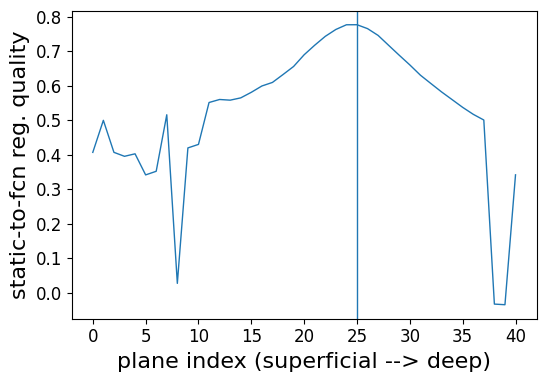

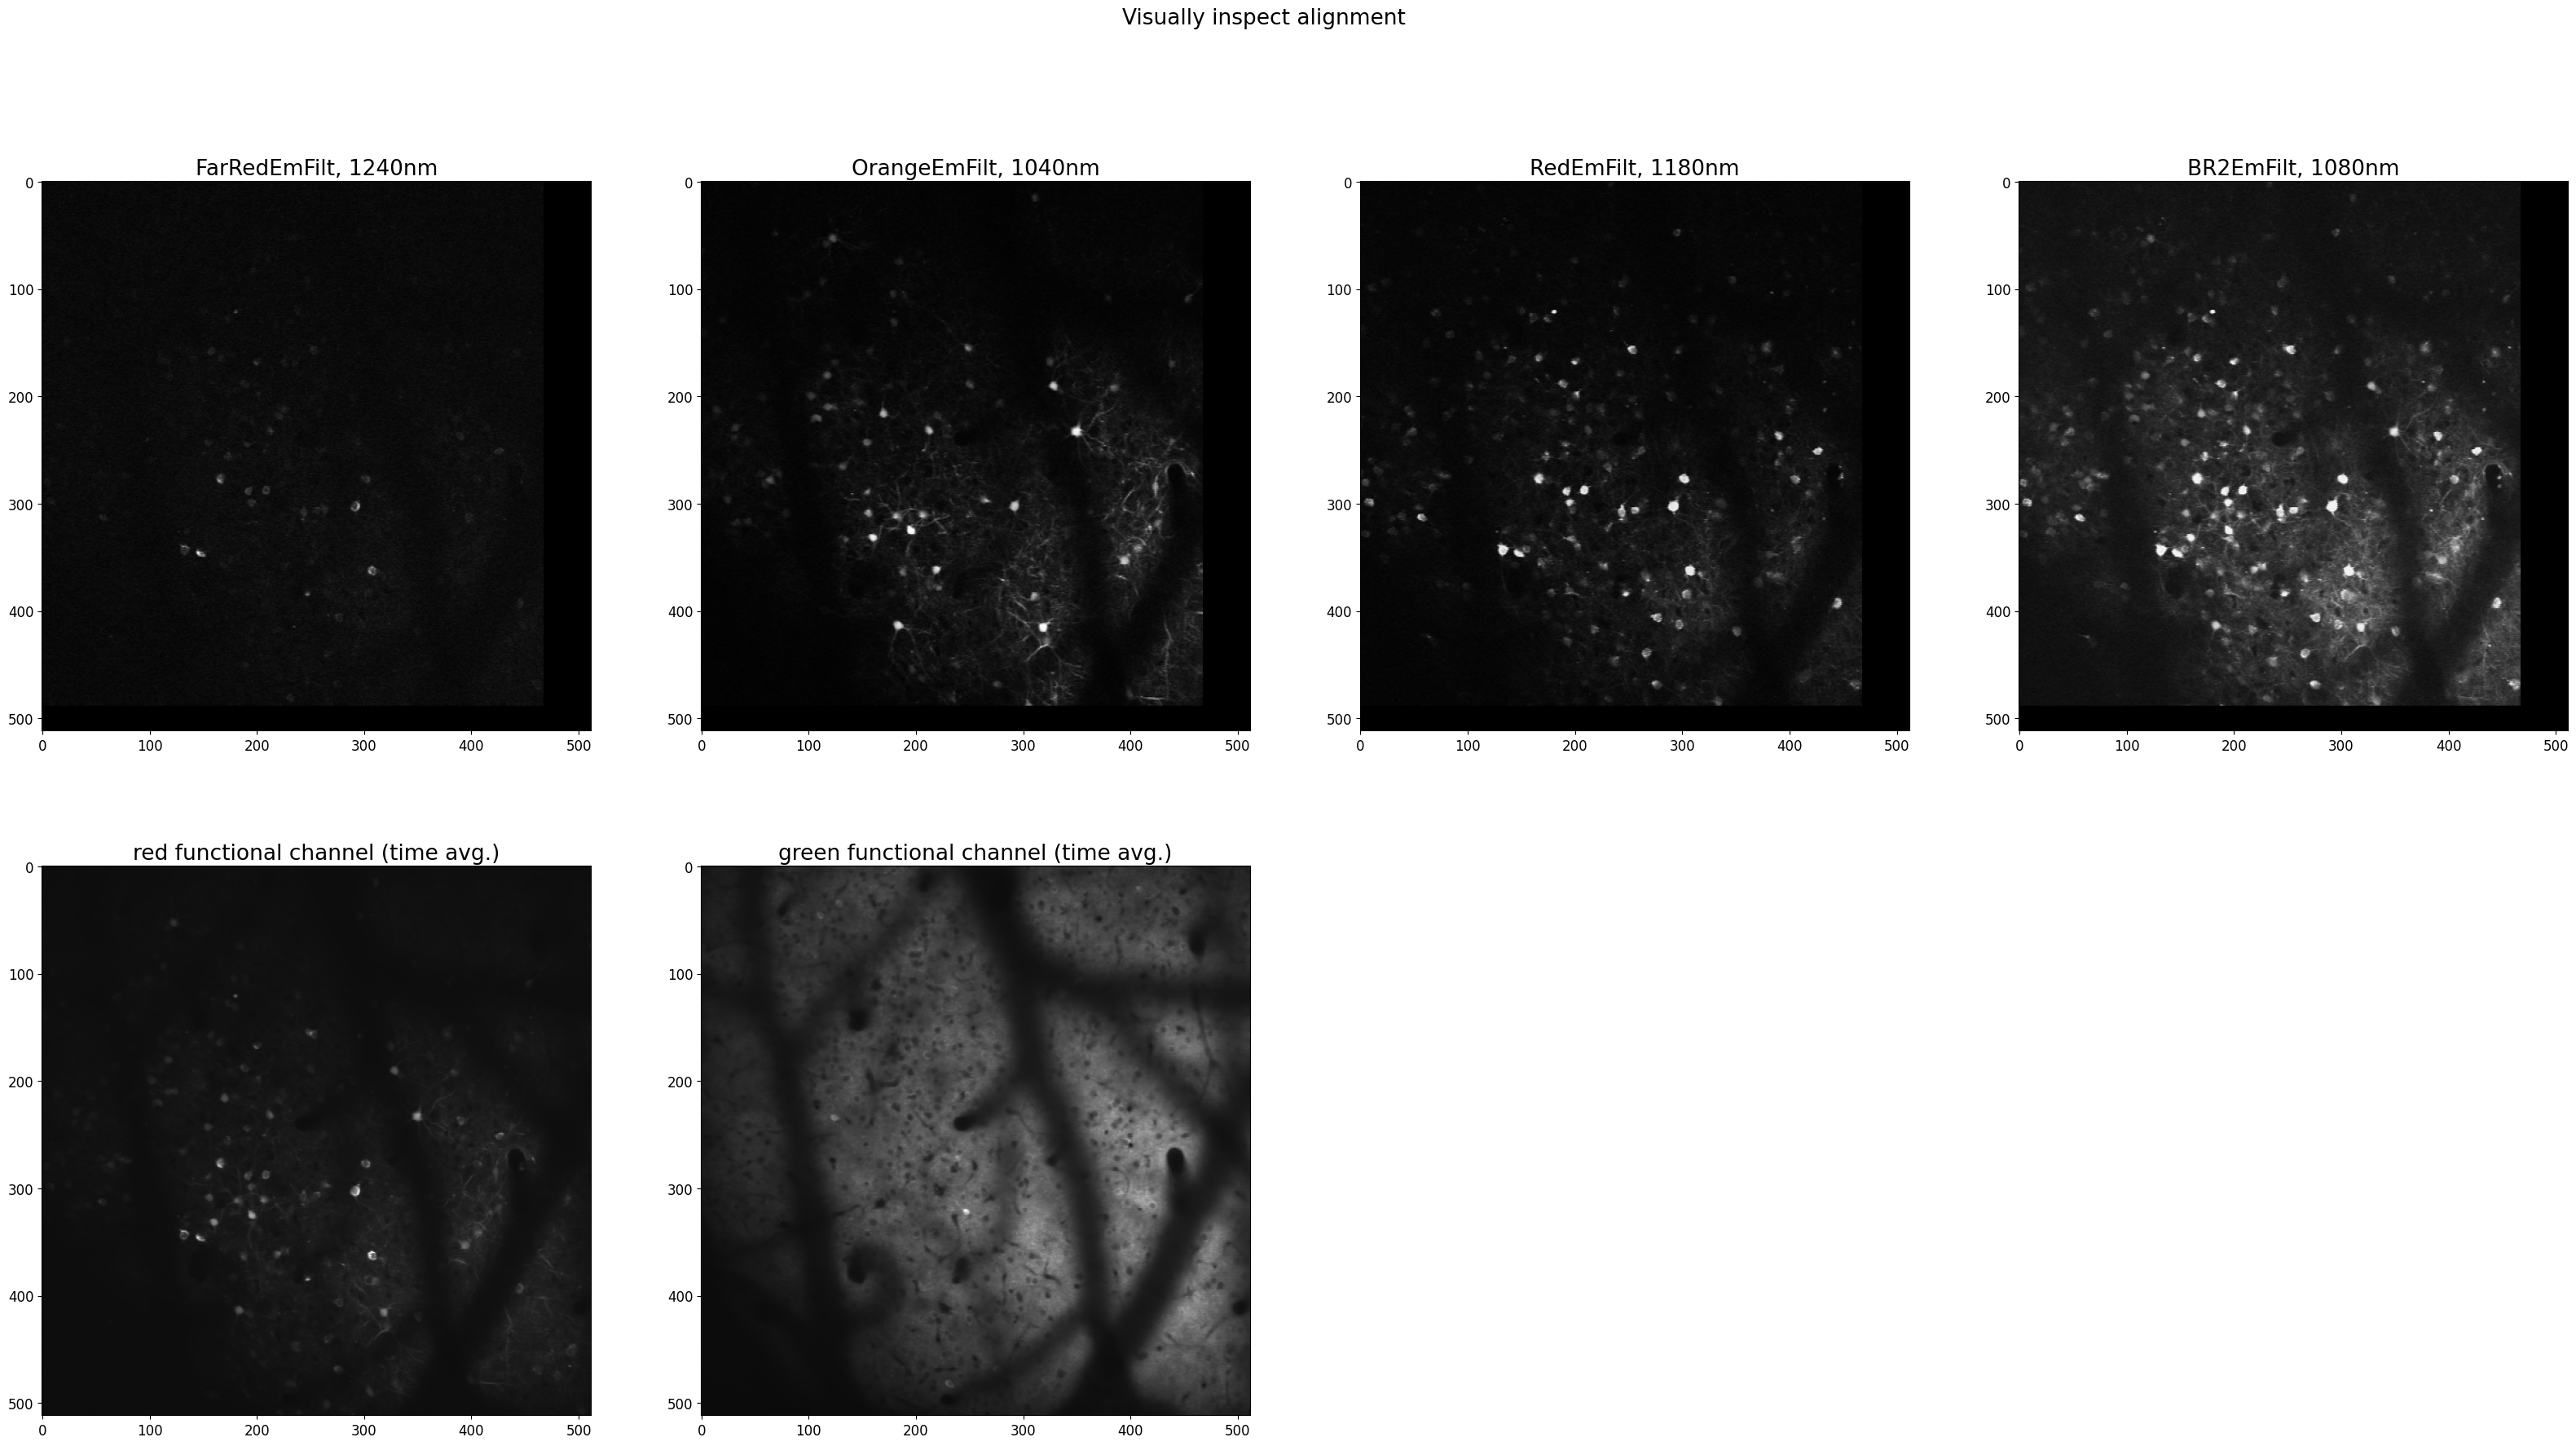

In [13]:
if not with_func:
    print("Skipping this code block since with_func = False (classification only, no trace extraction)\nWill run classification on middle plane")
    best_plane = np.floor(len(multi_dict["all reg"])/2).astype(int) # perform classification on middle plane
else:
    suite2p_path = os.path.join(os.path.join(os.path.join(func_dir, "interleaved"), "suite2p"), "plane0")
    ops = np.load(os.path.join(suite2p_path, "ops.npy"), allow_pickle=True)[()]
    stat = np.load(os.path.join(suite2p_path, "stat.npy"), allow_pickle=True)
    iscell = np.load(os.path.join(suite2p_path, "iscell.npy"), allow_pickle=True)
    
    red_func_cor = ops["meanImg_chan2"]
    reg_quality = np.full((len(multi_dict["all reg"]), ), np.nan)
    for plane in range(len(multi_dict["all reg"])):
        mov_image = np.reshape(multi_dict["all reg"][plane][:, ref_stack_idx], multi_dict["original shape"])
        shift_estimate, _, _ = phase_cross_correlation(red_func_cor, mov_image, upsample_factor=10)
        registered_image = shift(mov_image, shift=shift_estimate, mode="constant", cval=0)
        reg_quality[plane] = np.corrcoef(registered_image.flatten(), red_func_cor.flatten())[0, 1]
    
    # plot registration quality vs. plane index
    plt.figure(figsize=(6, 4))
    plt.plot(reg_quality, linewidth=1)
    plt.xlabel("plane index (superficial --> deep)")
    plt.ylabel("static-to-fcn reg. quality")
    
    best_plane = np.argmax(reg_quality)
    plt.axvline(best_plane, linewidth=1)

    savepath = os.path.join(fig_dir, "static_to_func_algn")
    if len(glob(savepath + ".*"))>0:
        print("Warning: overwriting previously saved figure.")
    plt.savefig(savepath, dpi=800)

    mov_image = np.reshape(multi_dict["all reg"][best_plane][:, ref_stack_idx], multi_dict["original shape"])
    func_shift, _, _ = phase_cross_correlation(red_func_cor, mov_image, upsample_factor=10) # func_shift is the translation that maps the functional images into the static image space
    
    # now apply this shift to all the static images
    for plane in range(len(multi_dict["all reg"])):
        for i in range(multi_dict["all reg"][plane].shape[1]):
            curr_img = np.reshape(multi_dict["all reg"][plane][:, i], multi_dict["original shape"])
            curr_img = shift(curr_img, shift=func_shift, mode="constant", cval=0).flatten()
            multi_dict["all reg"][plane][:, i] = curr_img

# quality control plot
fig, axs = plt.subplots(2, len(classification_chan["filter"])+1, figsize=(40, 20)) # first row: static, second row: func avg
fig.suptitle("Visually inspect alignment")

fac = 1 # contrast

# classification channels
idx = np.where(in_classification_chan)[0]
for i in range(len(idx)):
    curr_img = np.reshape(multi_dict["all reg"][best_plane][:, idx[i]], multi_dict["original shape"])
    axs[0, i].imshow(curr_img, vmin=0, vmax=np.max(curr_img)/fac, cmap="grey")
    axs[0, i].set_title(multi_dict["filter"][idx[i]] + ", " + str(multi_dict["wavelength"][idx[i]].astype(int)) + "nm")

# master image
curr_img = np.reshape(multi_dict["all reg"][best_plane][:, ref_stack_idx], multi_dict["original shape"])
axs[0, -1].imshow(curr_img, vmin=0, vmax=np.max(curr_img)/fac, cmap="grey")
axs[0, -1].set_title(multi_dict["filter"][ref_stack_idx] + ", " + str(multi_dict["wavelength"][ref_stack_idx].astype(int)) + "nm")

del_start = 0
if with_func:
    # functional images
    curr_img = ops["meanImg_chan2"]
    axs[1, 0].imshow(curr_img, vmin=0, vmax=np.max(curr_img)/fac, cmap="grey")
    axs[1, 0].set_title("red functional channel (time avg.)")
    
    curr_img = ops["meanImg"]
    axs[1, 1].imshow(curr_img, vmin=0, vmax=np.max(curr_img)/fac, cmap="grey")
    axs[1, 1].set_title("green functional channel (time avg.)")
    del_start = 2

for i in range(del_start, axs.shape[1]):
    axs[1, i].axis("off")

savepath = os.path.join(fig_dir, "alignment_QC")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=800)

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Run cellpose on master static image</p>

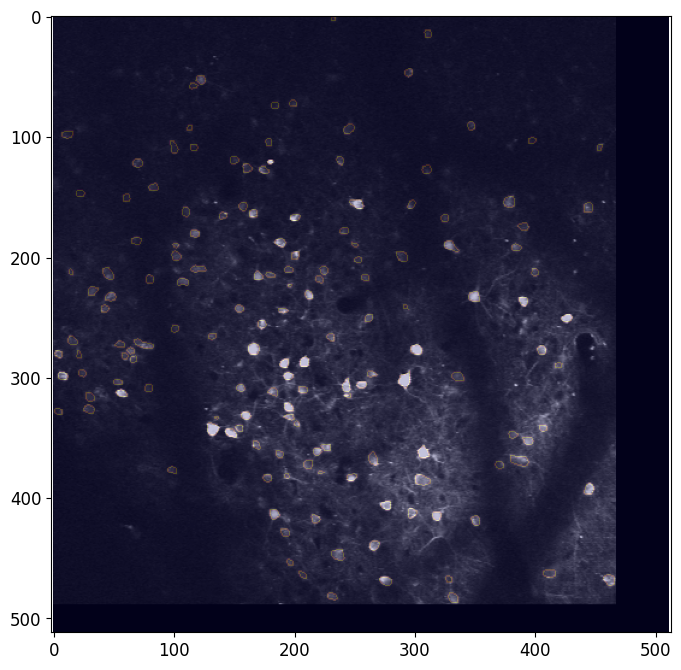

In [14]:
# now run cellpose (select the appropriate plane, namely, best_plane)
from cellpose import models, plot

if with_func:
    cellpose_dir = os.path.join(os.path.join(func_dir, "interleaved"), "cellpose")
else:
    cellpose_dir = os.path.join(multi_dir, "cellpose")

if os.path.isdir(cellpose_dir):
    print("May have already ran cellpose.")
    path = os.path.join(cellpose_dir, "ROIs.npy")
    if os.path.exists(path):
        print("Loaded previous cellpose output.")
        res = [np.load(path)]
    else:
        print("Warning: could not find previous cellpose output. May need to delete the cellpose folder and run cellpose again.")
else:
    # Load the Cellpose model (choose model_type='cyto' or 'nuclei' as needed)
    model = models.Cellpose(model_type='cyto', gpu=True)  # Set gpu=False if no GPU
    
    # Run segmentation; diameter set to None for automatic
    master_image = np.reshape(multi_dict["all reg"][best_plane][:, ref_stack_idx], multi_dict["original shape"])
    res = list(model.eval(master_image, diameter=cellpose_diameter, channels=[0,0])) # change diameter back to None!

    # erode ROIs 
    res[0] = erode_rois(labels=res[0], nLayers=nLayers_erode)
    
    # save the results in func_dir/interleaved/cellpose directory
    os.mkdir(cellpose_dir)
    np.save(os.path.join(cellpose_dir, "ROIs.npy"), res[0])
    
    # visualize segmentation
    from cellpose.utils import outlines_list, masks_to_outlines
    
    outlines = masks_to_outlines(res[0])
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(master_image, cmap="grey", vmin=0, vmax=np.max(master_image))
    ax.imshow(outlines, cmap="plasma", alpha=0.2)
    ax.axis("equal")
    plt.savefig(os.path.join(fig_dir, "cellpose_ROIs_master_img_overlay"), dpi=500)

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Perform pixelwise classification (using cellpose ROIs as a template); then classify each ROI</p>

In [15]:
template = (res[0]>0).flatten() # pixels contained in a cellpose ROI

# channels used for classification are stored in 'in_classification_chan'

# reorganize ground truth response profiles
gt_vec = []
for fp in fp_dict.keys():
    curr = np.array(fp_dict[fp]['multi aligned'][in_classification_chan])
    gt_vec.append(curr/np.linalg.norm(curr))
gt_vec = np.column_stack(gt_vec)

# compute angles with pixelwise responses
multi_temp = multi_dict['all reg'][best_plane][:, in_classification_chan]
multi_temp_norm = np.divide(multi_temp, np.reshape(np.linalg.norm(multi_temp, axis=1), (-1, 1)))
cosines = np.dot(multi_temp_norm, gt_vec) # output is in shape (nPixels, nFPs)
classes = np.argmax(cosines, axis=1).astype(float) # classify by min angle

# exclude pixels outside of cellpose template
cosines[~template, :] = np.nan 
classes[~template] = np.nan

# classify cellpose ROIs
numROIs = np.max(res[0]) # number of cellpose ROIs
frac = np.full((numROIs, len(fp_dict.keys())), np.nan) # entry (n, i) is fraction of pixels in ROI n classified as FP i

resh_ROIs = res[0].flatten() # unfurl cellpose ROIs to 1D array
for ROI_idx in range(1, numROIs+1):
    keep = (resh_ROIs==ROI_idx)
    if np.sum(keep)>0:
        for i in range(frac.shape[1]):
            frac[ROI_idx-1, i] = np.sum(classes[keep]==i)/np.sum(keep)
    else:
        print("warning: empty ROI?")

# final classification (save results; need to add this)
classified_ROIs = (frac>ROI_frac)
for i in range(frac.shape[1]):
    print("number of ROIs classified as " + list(fp_dict.keys())[i] + " = " + str(np.sum(classified_ROIs[:, i])))

# save results
keys = list(fp_dict.keys())
values = np.transpose(classified_ROIs)
saver = dict(zip(keys, values))
path = os.path.join(cellpose_dir, "classification")

if len(glob(path + ".*"))>0:
    print("Warning: overwriting previously saved classification output")

np.save(path, saver)

values2 = np.transpose(frac)
saver2 = dict(zip(keys, values2))
path2 = os.path.join(cellpose_dir, "pixel_ratios")

if len(glob(path2 + ".*"))>0:
    print("Warning: overwriting previously saved pixel ratios")
np.save(path2, saver2)

/var/folders/ck/ps9sgkzx46l12kw1d2g0c89c0000gn/T/ipykernel_6156/3642051860.py:14: RuntimeWarning: invalid value encountered in divide
  multi_temp_norm = np.divide(multi_temp, np.reshape(np.linalg.norm(multi_temp, axis=1), (-1, 1)))


number of ROIs classified as mCherry = 80
number of ROIs classified as mNeptune = 2
number of ROIs classified as tdTomato = 43


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Classification QC figures</p>

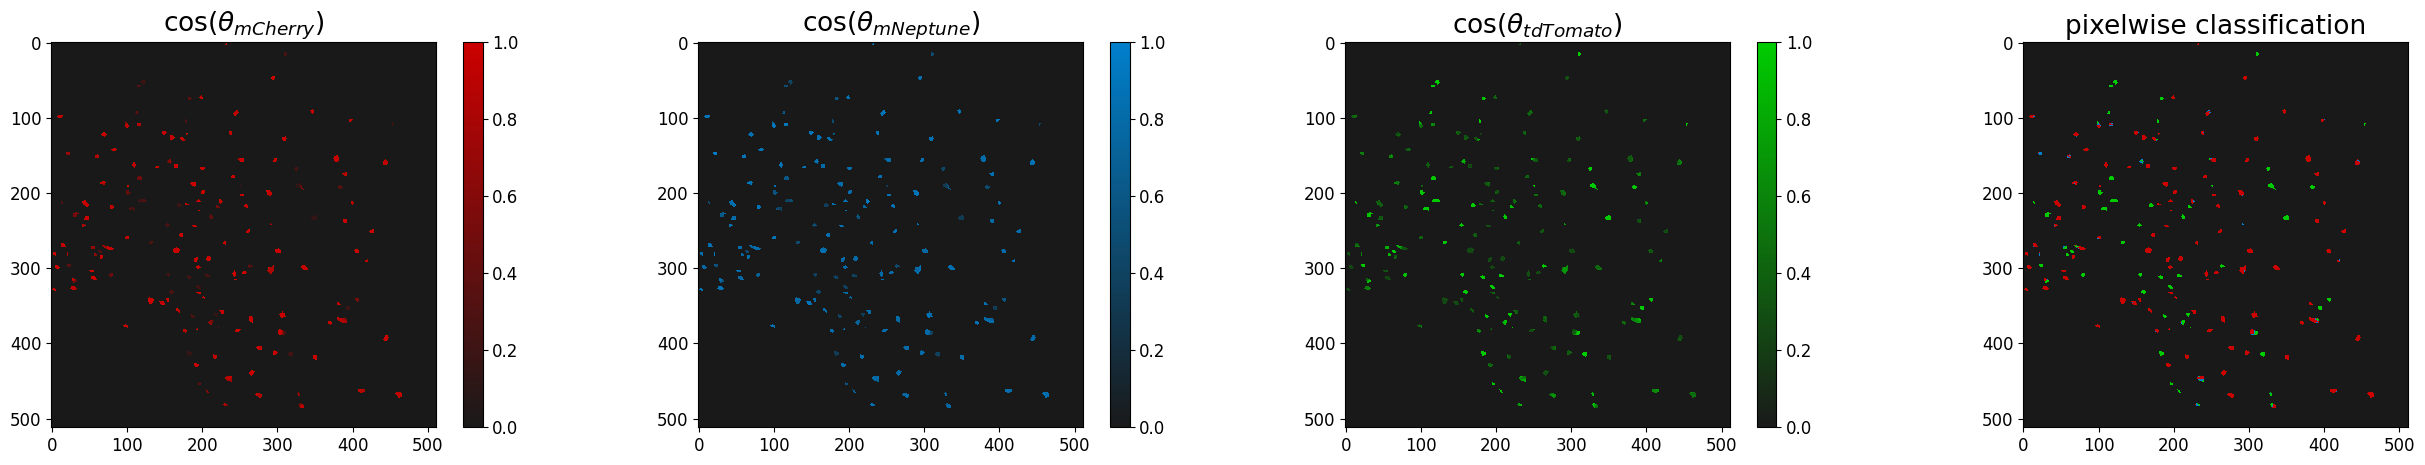

In [16]:
cols = [[0.8, 0, 0], [0, 0.5, 0.8], [0, 0.8, 0], [0.1, 0.1, 0.1]] # colors representing the different FPs
fig, axs = plt.subplots(1, len(fp_dict.keys())+1, figsize=(32, 5))
fade_cmap = []
for i in range(len(fp_dict.keys())):
    cmap = mcolors.LinearSegmentedColormap.from_list("fade_cmap", [cols[-1], cols[i]])
    cmap.set_bad(color=cols[-1])
    fade_cmap.append(cmap)
    
for i in range(len(fp_dict.keys())):
    pp = axs[i].imshow(np.reshape(cosines[:, i], multi_dict["original shape"]), vmin=0, vmax=1, cmap=fade_cmap[i])
    fig.colorbar(pp, ax=axs[i])
    axs[i].set_title("cos($\\theta_{" + list(fp_dict.keys())[i] + "})$")

cmap = mcolors.ListedColormap(cols[:-1])
cmap.set_bad(color=cols[-1])
axs[-1].imshow(np.reshape(classes, multi_dict["original shape"]), cmap=cmap)
axs[-1].set_title("pixelwise classification")

savepath = os.path.join(fig_dir, "pixelwise_angles_and_classification")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=800)

/var/folders/ck/ps9sgkzx46l12kw1d2g0c89c0000gn/T/ipykernel_6156/4108956350.py:3: RuntimeWarning: invalid value encountered in divide
  multi_plot_norm = np.divide(multi_plot, np.reshape(np.linalg.norm(multi_plot, axis=1), (-1, 1)))


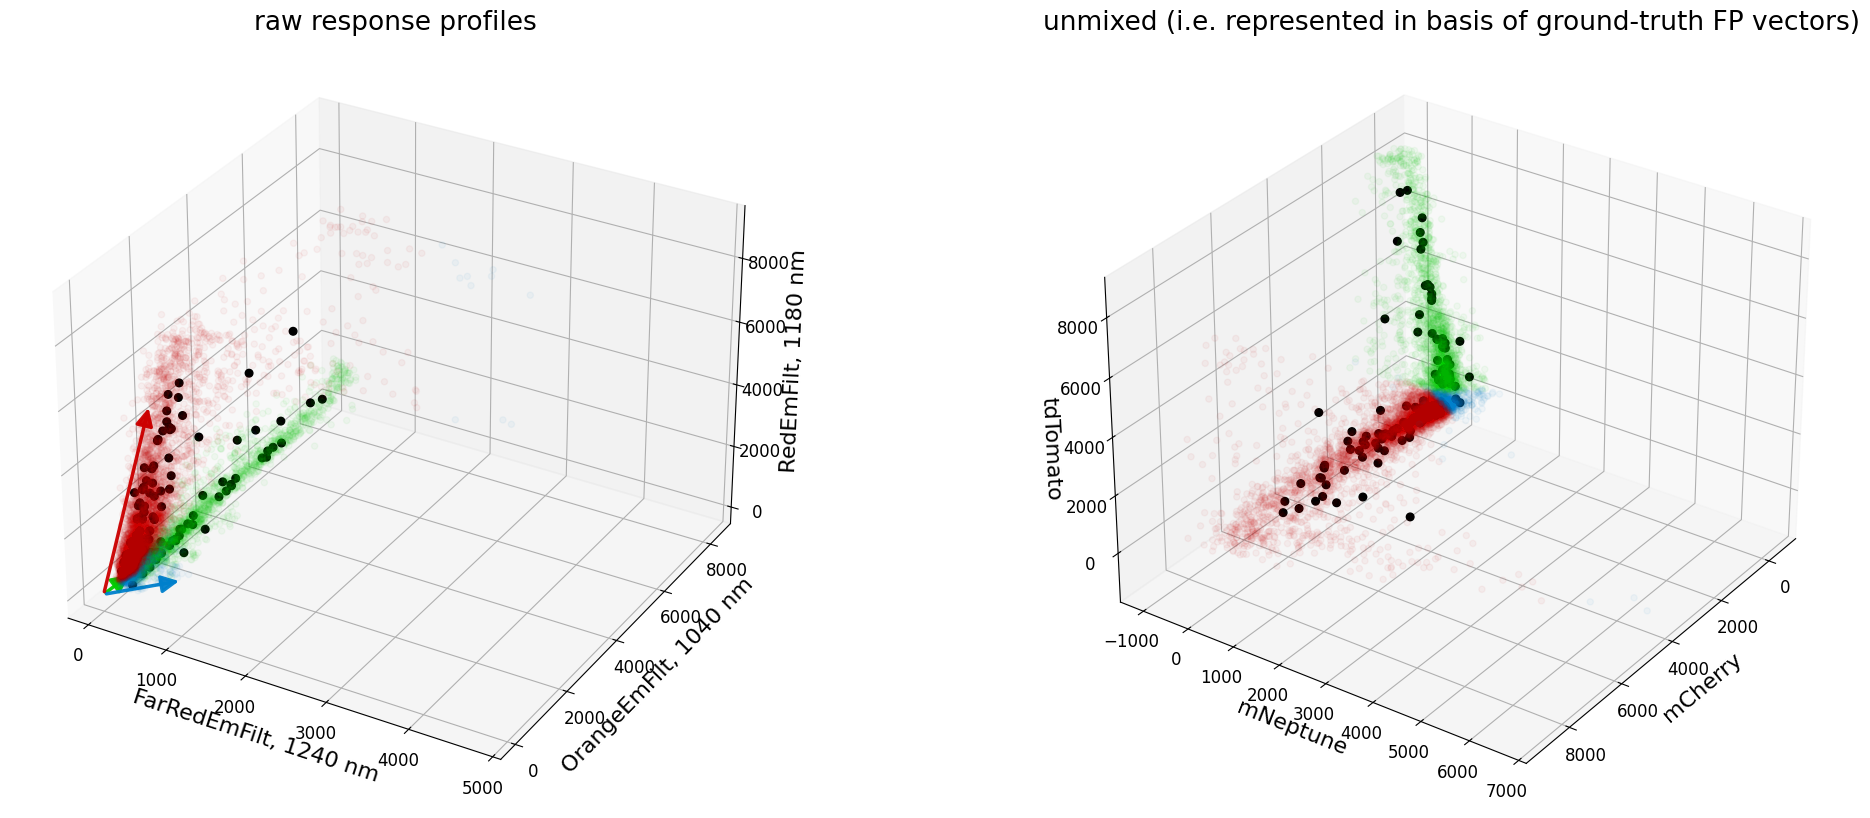

In [17]:
# need to change this to be compatible with plot_chan
multi_plot = multi_dict['all reg'][best_plane][:, in_plot_chan]
multi_plot_norm = np.divide(multi_plot, np.reshape(np.linalg.norm(multi_plot, axis=1), (-1, 1)))

# compute means over ROIs
mean_cos = np.full(frac.shape, np.nan) # numROIs x numFPs
mean_intensity = np.full((numROIs, multi_plot.shape[1]), np.nan) # numROIs x numChannels (compute these later, DELETE)

resh_ROIs = res[0].flatten() # unfurl cellpose ROIs to 1D array
for ROI_idx in range(1, numROIs+1):
    keep = (resh_ROIs==ROI_idx)
    if np.sum(keep)>0:
        for i in range(len(fp_dict.keys())):
            mean_cos[ROI_idx-1, i] = np.mean(cosines[keep])

        mean_intensity[ROI_idx-1, :] = np.mean(multi_plot[keep, :], axis=0)
    else:
        print("warning: empty ROI?")

# ground truth vectors (unnormalized) in plot_chan
gt_vec_plot_unnorm = []
for fp in fp_dict.keys():
    curr = np.array(fp_dict[fp]['multi aligned'][in_plot_chan])
    gt_vec_plot_unnorm.append(curr)
gt_vec_plot_unnorm = np.column_stack(gt_vec_plot_unnorm)


# scatter plots of pixelwise responses
fig = plt.figure(figsize=(25, 10))
ax = fig.add_subplot(121, projection='3d')
keep = ~np.isnan(classes)
ax.scatter(multi_plot[keep, 0], multi_plot[keep, 1], multi_plot[keep, 2], c=classes[keep], cmap=cmap, alpha=0.04)

# now show mean (across pixels) intensity profile for each classified ROI
for f in range(len(fp_dict.keys())):
    curr = classified_ROIs[:, f]
    ax.scatter(mean_intensity[curr, 0], mean_intensity[curr, 1], mean_intensity[curr, 2], c='k', s=30, alpha=1)
ax.set_title('raw response profiles')

# channel labels
labels = []
for i in range(3):
    labels.append(multi_dict['filter'][in_plot_chan][i] + ", " + str(multi_dict['wavelength'][in_plot_chan][i].astype(int)) + " nm")

setters = [ax.set_xlabel, ax.set_ylabel, ax.set_zlabel]

for label, setter in zip(labels, setters):
    setter(label)
    
# add ground-truth arrows
starts = np.zeros((gt_vec_plot_unnorm.shape[1], gt_vec_plot_unnorm.shape[0]))
ends = np.transpose(np.array(gt_vec_plot_unnorm))
for s, e, c in zip(starts, ends, cols[:-1]):
    add_arrow3d(ax, s, e, color=c)

# add panel showing unmixed pixels
ax2 = fig.add_subplot(122, projection='3d')
#unmixed = np.linalg.inv(gt_vec)@np.transpose(multi_temp)
#unmixed_ROIs = np.linalg.inv(gt_vec)@np.transpose(mean_intensity)
unmixed = np.full((len(fp_dict.keys()), multi_temp.shape[0]), np.nan)
for p in range(multi_temp.shape[0]):
    unmixed[:, p] = np.linalg.lstsq(gt_vec, np.transpose(multi_temp[p, :]))[0]

unmixed_ROIs = np.full((len(fp_dict.keys()), numROIs), np.nan)
for n in range(numROIs):
    unmixed_ROIs[:, n] = np.linalg.lstsq(gt_vec, np.transpose(mean_intensity[n, :]))[0]

ax2.scatter(unmixed[0, keep], unmixed[1, keep], unmixed[2, keep], c=classes[keep], cmap=cmap, alpha=0.04)
for f in range(len(fp_dict.keys())):
    curr = classified_ROIs[:, f]
    ax2.scatter(unmixed_ROIs[0, curr], unmixed_ROIs[1, curr], unmixed_ROIs[2, curr], c='k', s=30, alpha=1)
    
lab = list(fp_dict.keys())
ax2.set_xlabel(lab[0])
ax2.set_ylabel(lab[1])
ax2.set_zlabel(lab[2])
ax2.view_init(elev=30, azim=35)
ax2.set_title('unmixed (i.e. represented in basis of ground-truth FP vectors)')

savepath = os.path.join(fig_dir, "pixelwise_response_profiles")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=800)

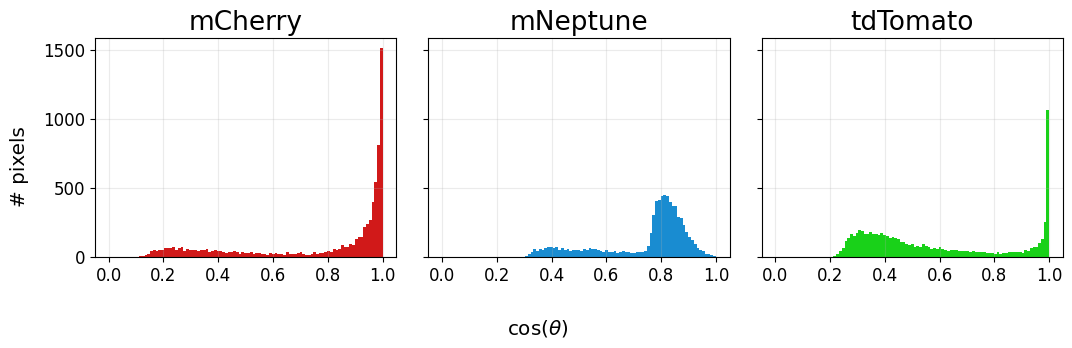

In [18]:
fig, axes = plt.subplots(1, len(fp_dict.keys()), figsize=(11, 3.5), sharey=True)

for j, ax in enumerate(axes):
    # drop NaNs
    data = cosines[:, j]
    data = data[~np.isnan(data)]
    bins = np.linspace(0, 1, 100)
    if data.size > 0:
        ax.hist(data, bins=bins, color=cols[j], edgecolor='none', alpha=0.9)
    else:
        ax.text(0.5, 0.5, 'all NaN', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(list(fp_dict.keys())[j])
    ax.grid(True, alpha=0.25)

fig.supylabel('# pixels')
fig.supxlabel('cos($\\theta$)')
fig.tight_layout()

savepath = os.path.join(fig_dir, "angle_distributions")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=500)

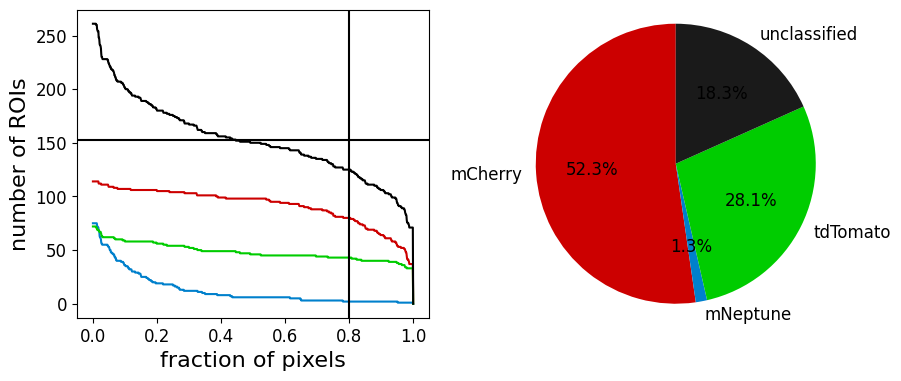

In [19]:
thresh = np.linspace(0, 1, 1000)
num2 = np.full((len(thresh), len(fp_dict.keys())), np.nan)

for i in range(len(thresh)):
    num2[i, :] = np.sum(frac>thresh[i], axis=0)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for f in range(frac.shape[1]):
    axs[0].plot(thresh, num2[:, f], color=cols[f])
axs[0].plot(thresh, np.sum(num2, axis=1), color="k")
axs[0].axhline(frac.shape[0], color="k")
axs[0].axvline(ROI_frac, color="k")
axs[0].set_xlabel("fraction of pixels")
axs[0].set_ylabel("number of ROIs")


# make pie charts showing classified ROIs
sizes = np.concatenate((np.sum(classified_ROIs, axis=0), [np.sum(np.sum(classified_ROIs, axis=1)==0)]))
sizes = sizes/np.sum(sizes)
labels = list(fp_dict.keys())
labels.append("unclassified")

# Create pie chart
axs[1].pie(sizes, labels=labels, colors=cols, autopct='%1.1f%%', startangle=90)
axs[1].axis('equal')

savepath = os.path.join(fig_dir, "summary_classification")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=500)

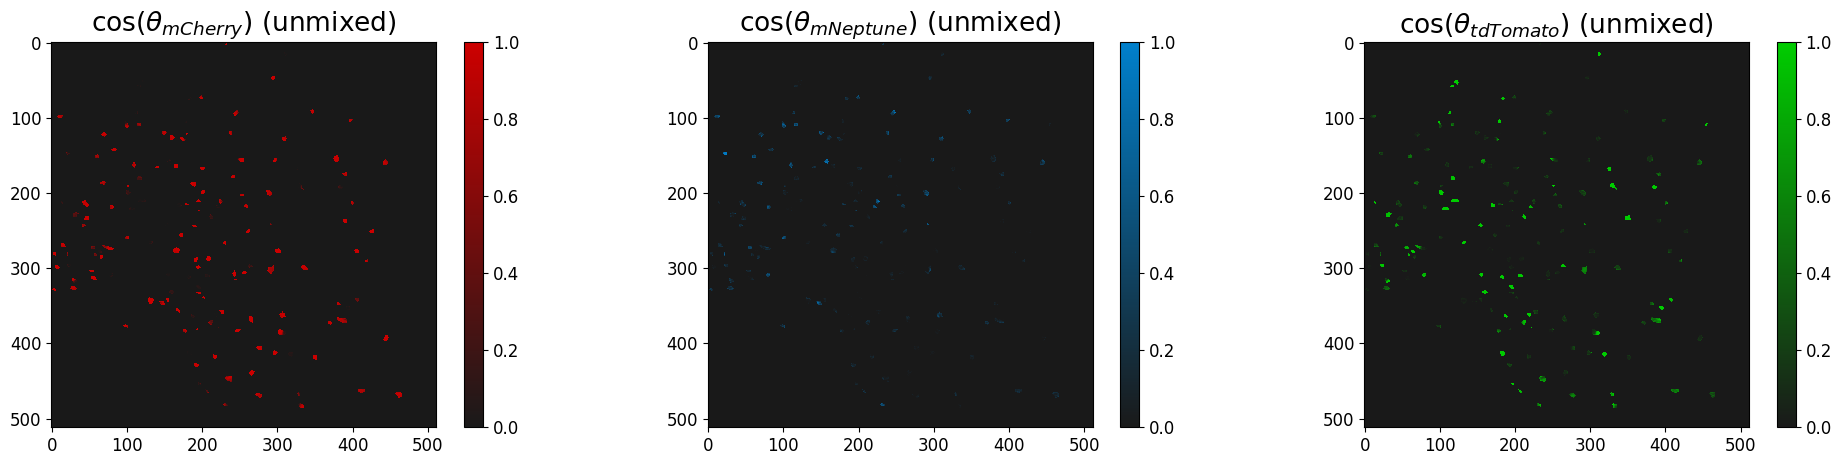

In [20]:
fig, axs = plt.subplots(1, len(fp_dict.keys()), figsize=(24, 5))
unmixed2 = unmixed.copy()
unmixed2[:, ~template] = np.nan 
unmixed2 = np.divide(unmixed2, np.linalg.norm(unmixed2, axis=0))
for i in range(len(fp_dict.keys())):
    pp = axs[i].imshow(np.reshape(unmixed2[i, :], multi_dict["original shape"]), vmin=0, vmax=1, cmap=fade_cmap[i])
    fig.colorbar(pp, ax=axs[i])
    axs[i].set_title("cos($\\theta_{" + list(fp_dict.keys())[i] + "})$ (unmixed)")

savepath = os.path.join(fig_dir, "unmixed_pixelwise_response_profiles")
if len(glob(savepath + ".*"))>0:
    print("Warning: overwriting previously saved figure.")
plt.savefig(savepath, dpi=800)

<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>Extract functional traces from cellpose ROIs, then combine with suite2p ROIs (combined output saved in interleaved/suite2p/plane0 directory)</p>

In [22]:
from suite2p.extraction import masks, extract
from suite2p.detection import stats
from suite2p.io import binary

if not with_func:
    print("Skipping this code block since with_func = False (classification only, no trace extraction)")
else: 
    ops = np.load(os.path.join(suite2p_path, "ops.npy"), allow_pickle=True)
    stat_old = np.load(os.path.join(suite2p_path, "stat.npy"), allow_pickle=True)

    # convert cellpose masks to suite2p stat format
    temp = np.array(labels_to_stat(res[0]))
    stat_new_temp = stats.roi_stats(temp, res[0].shape[0], res[0].shape[1], aspect=None, diameter=None, max_overlap=None, do_crop=True)

    # create neuropil masks, extract traces for cellpose ROIs
    stat_new, F_new, Fneu_new, F_chan2_new, Fneu_chan2_new = extract.create_masks_and_extract(ops=ops[()], stat=stat_new_temp)

    # check for overlap (remove suite2p ROIs that overlap > overlap_threshold with a cellpose ROI)
    keep = np.full((len(stat_old),), True)
    for i in range(len(stat_old)):
        ypix_old = stat_old[i]['ypix']
        xpix_old = stat_old[i]['xpix']
        A = np.column_stack((ypix_old.ravel(), xpix_old.ravel()))
        A_view = A.view([('', A.dtype)]*2).ravel()
        max_overlap = 0
        for j in range(len(stat_new)):
            ypix_new = stat_new[j]['ypix']
            xpix_new = stat_new[j]['xpix']
            B = np.column_stack((ypix_new.ravel(), xpix_new.ravel()))
            B_view = B.view([('', B.dtype)]*2).ravel()
            max_overlap = np.max([max_overlap, np.isin(A_view, B_view).sum() / len(ypix_old)])

        keep[i] = max_overlap<=overlap_threshold
        
    stat = np.concatenate((stat_old[keep], stat_new))

    # load suite2p ROI traces
    F_old = np.load(os.path.join(suite2p_path, "F.npy"), allow_pickle=True)
    Fneu_old = np.load(os.path.join(suite2p_path, "Fneu.npy"), allow_pickle=True)
    F_chan2_old = np.load(os.path.join(suite2p_path, "F_chan2.npy"), allow_pickle=True)
    Fneu_chan2_old = np.load(os.path.join(suite2p_path, "Fneu_chan2.npy"), allow_pickle=True)

    # combine
    F = np.concatenate((F_old[keep, :], F_new), axis=0)
    Fneu = np.concatenate((Fneu_old[keep, :], Fneu_new), axis=0)
    F_chan2 = np.concatenate((F_chan2_old[keep, :], F_chan2_new), axis=0)
    Fneu_chan2 = np.concatenate((Fneu_chan2_old[keep, :], Fneu_chan2_new), axis=0)

    iscell_old = np.load(os.path.join(suite2p_path, "iscell.npy"), allow_pickle=True)
    iscell_new = np.ones((F_new.shape[0], 2))
    iscell = np.concatenate((iscell_old[keep, :], iscell_new), axis=0)
    
    redcell_old = np.zeros(iscell_old[keep, :].shape) # all of the old cells (minus those removed due to overlap) are not red
    redcell_new = np.ones(iscell_new.shape) # all of the new cells are red per cellpose 
    redcell = np.concatenate((redcell_old, redcell_new), axis=0)

    # NOTE: this is a bandaid, need to add spike detection for cellpose ROIs
    spks_old = np.load(os.path.join(suite2p_path, "spks.npy"), allow_pickle=True)
    spks_new = np.zeros((stat_new.shape[0], spks_old.shape[1]))
    spks = np.concatenate((spks_old[keep, :], spks_new))

    # rename all the original suite2p outputs (add "_orig")
    os.rename(os.path.join(suite2p_path, "stat.npy"), os.path.join(suite2p_path, "stat_orig.npy"))
    os.rename(os.path.join(suite2p_path, "F.npy"), os.path.join(suite2p_path, "F_orig.npy"))
    os.rename(os.path.join(suite2p_path, "Fneu.npy"), os.path.join(suite2p_path, "Fneu_orig.npy"))
    os.rename(os.path.join(suite2p_path, "F_chan2.npy"), os.path.join(suite2p_path, "F_chan2_orig.npy"))
    os.rename(os.path.join(suite2p_path, "Fneu_chan2.npy"), os.path.join(suite2p_path, "Fneu_chan2_orig.npy"))
    os.rename(os.path.join(suite2p_path, "iscell.npy"), os.path.join(suite2p_path, "iscell_orig.npy"))
    os.rename(os.path.join(suite2p_path, "redcell.npy"), os.path.join(suite2p_path, "redcell_orig.npy"))
    os.rename(os.path.join(suite2p_path, "spks.npy"), os.path.join(suite2p_path, "spks_orig.npy"))
    
    # save combined files
    np.save(os.path.join(suite2p_path, "F.npy"), F)
    np.save(os.path.join(suite2p_path, "Fneu.npy"), Fneu)
    np.save(os.path.join(suite2p_path, "F_chan2.npy"), F_chan2)
    np.save(os.path.join(suite2p_path, "Fneu_chan2.npy"), Fneu_chan2)
    np.save(os.path.join(suite2p_path, "iscell.npy"), iscell)
    np.save(os.path.join(suite2p_path, "redcell.npy"), redcell)
    np.save(os.path.join(suite2p_path, "stat.npy"), stat)
    np.save(os.path.join(suite2p_path, "spks.npy"), spks)

Masks created, 0.23 sec.
Extracted fluorescence from 153 ROIs in 15235 frames, 1005.01 sec.
Extracted fluorescence from 153 ROIs in 15235 frames, 1392.11 sec.


<div style="font-size: 1.8em; line-height: 1.5em;">
  <p>At this point, you can inspect the combined output by dragging and dropping ${func_dir}/interleaved/suite2p/plane0/stat.npy into the suite2p GUI</p>